In [2]:
import numpy as np
import matplotlib.pyplot as plt
import firtez_dz as frz
from astropy.io import fits
from matplotlib.colors import CenteredNorm, TwoSlopeNorm
np.random.seed(22)

In [3]:
plt.rc('text', usetex = False)

In [4]:
syn = frz.read_profile('/dat/xenosh/muram_plage_pore/20000/stokes.bin')

In [5]:
sim = frz.read_model('/dat/xenosh/muram_plage_pore/20000/muram_020000_nx1536_ny1536_nz240_d6.bin')

In [6]:
atm = fits.open('/dat/xenosh/sharing/new2_tau.fits')[0].data

In [ ]:
#tau,tem,pg,rho,vmic,vz,bx,by,bz

In [7]:
# interpolate
tau_common = np.linspace(-3,1,41)
nx = sim.tem.shape[0]
ny = sim.tem.shape[1]
nz = tau_common.shape[0]
T= np.zeros((nx,ny,nz))
P= np.zeros((nx,ny,nz))
Bx= np.zeros((nx,ny,nz))
By= np.zeros((nx,ny,nz))
Bz= np.zeros((nx,ny,nz))
Vz= np.zeros((nx,ny,nz))
Bh = np.zeros((nx,ny,nz))
a = np.zeros((nz))
for i in range(nx):
    for j in range(ny):
        T[i,j,:] = np.interp(tau_common, sim.tau[i,j,::-1], sim.tem[i,j,::-1])
        a = np.interp(tau_common, sim.tau[i,j,::-1], np.log10(sim.pg[i,j,::-1]))
        P[i,j,:] = 10 ** a
        Bx[i,j,:] = np.interp(tau_common, sim.tau[i,j,::-1], sim.bx[i,j,::-1])
        By[i,j,:] = np.interp(tau_common, sim.tau[i,j,::-1], sim.by[i,j,::-1])
        Bz[i,j,:] = np.interp(tau_common, sim.tau[i,j,::-1], sim.bz[i,j,::-1])
        Vz[i,j,:] = np.interp(tau_common, sim.tau[i,j,::-1], sim.vz[i,j,::-1])
        Bh[i,j,:] = np.sqrt(Bx[i,j,:]**2+By[i,j,:]**2)

In [8]:
B = np.sqrt(Bz**2+Bh**2)

In [ ]:
tau_common = tau_common[::-1]

In [128]:

T[:,:,:] = T[:,:,::-1]
P[:,:,:] = P[:,:,::-1]
Bx[:,:,:] = Bx[:,:,::-1]
By[:,:,:] = By[:,:,::-1]
Bz[:,:,:] = Bz[:,:,::-1]
Vz[:,:,:] = Vz[:,:,::-1]
Bh[:,:,:] = Bh[:,:,::-1]
B[:,:,:] = B[:,:,::-1]

## core, canopy, qs, oppo

In [ ]:
# sim

In [9]:
c1 = B[:,:,30]>1000
c2 = B[:,:,30]<100
core = np.argwhere(c1)
qs = np.argwhere(c2)

In [10]:
c3 = B[:,:,10] > 300
c4 = B[:,:,10] - B[:,:,30] > 50
c5 = B[:,:,30] < 1000
canopy = np.argwhere(c5 & c3 & c4)

In [11]:
c6 = Bz[:,:,30] < -50
c7 = B[:,:,10] > 300
oppo = np.argwhere(c6 & c7)

In [12]:
print(qs.shape)
print(core.shape)
print(canopy.shape)
print(oppo.shape)

(1220870, 2)
(484168, 2)
(609166, 2)
(135168, 2)


1.2581707176021546

In [ ]:
# obs

In [13]:
c1 = np.sqrt(atm[1,6,:,:,10]**2+atm[1,7,:,:,10]**2+atm[1,8,:,:,10]**2)>900
c2 = np.sqrt(atm[1,6,:,:,10]**2+atm[1,7,:,:,10]**2+atm[1,8,:,:,10]**2)<200
core_o = np.argwhere(c1)
qs_o = np.argwhere(c2)

In [14]:
c3 = np.sqrt(atm[1,6,:,:,30]**2+atm[1,7,:,:,30]**2+atm[1,8,:,:,30]**2) > 300
c4 = np.sqrt(atm[1,6,:,:,30]**2+atm[1,7,:,:,30]**2+atm[1,8,:,:,30]**2) - np.sqrt(atm[1,6,:,:,10]**2+atm[1,7,:,:,10]**2+atm[1,8,:,:,10]**2) > 50
c5 = np.sqrt(atm[1,6,:,:,10]**2+atm[1,7,:,:,10]**2+atm[1,8,:,:,10]**2) < 1000
canopy_o = np.argwhere(c5 & c3 & c4)

In [15]:
c6 = atm[1,8,:,:,10] > 50
c7 = np.sqrt(atm[1,6,:,:,30]**2+atm[1,7,:,:,30]**2+atm[1,8,:,:,30]**2) > 300
oppo_o = np.argwhere(c6 & c7)

In [16]:
print(qs_o.shape)
print(core_o.shape)
print(canopy_o.shape)
print(oppo_o.shape)

(6668, 2)
(3576, 2)
(3205, 2)
(591, 2)


0.8962527964205816

### example profile of opposite polarity

In [19]:
np.random.randint(oppo.shape[0])

24932

In [58]:
syn.stki[:,x,y].shape

(200,)

-68.13535584903681


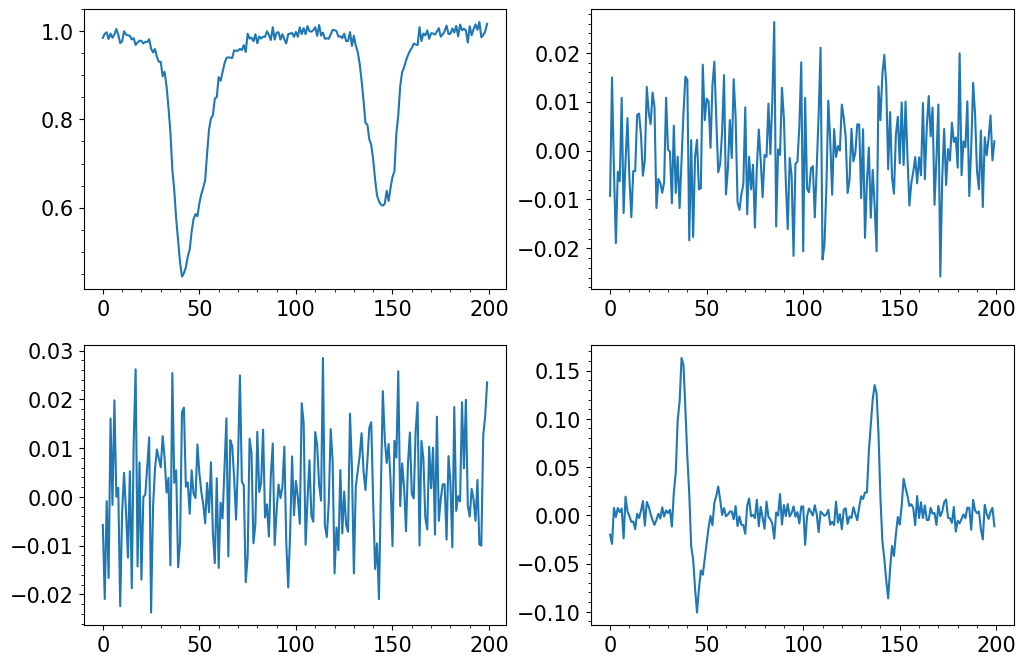

In [66]:
n = np.random.randint(oppo.shape[0])
x = oppo[n,0]
y = oppo[n,1]
plt.figure(figsize=(12,8))
plt.subplot(221)
plt.plot(syn.stki[:,x,y]+np.random.normal(loc=0, scale=1e-2, size=(200,)))
plt.subplot(222)
plt.plot(syn.stkq[:,x,y]+np.random.normal(loc=0, scale=1e-2, size=(200,)))
plt.subplot(223)
plt.plot(syn.stku[:,x,y]+np.random.normal(loc=0, scale=1e-2, size=(200,)))
plt.subplot(224)
plt.plot(syn.stkv[:,x,y]+np.random.normal(loc=0, scale=1e-2, size=(200,)))
print(Bz[oppo[n,0],oppo[n,1],30])

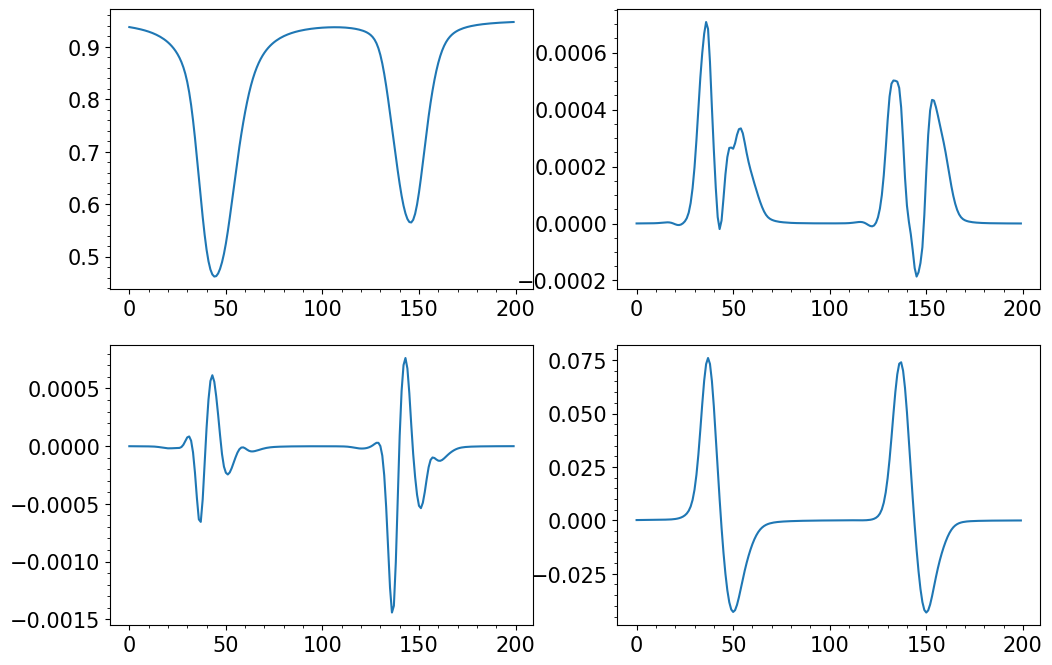

In [45]:
plt.figure(figsize=(12,8))
plt.subplot(221)
plt.plot(np.mean(syn.stki[:,oppo[:,0],oppo[:,1]],axis=1))
plt.subplot(222)
plt.plot(np.mean(syn.stkq[:,oppo[:,0],oppo[:,1]],axis=1))
plt.subplot(223)
plt.plot(np.mean(syn.stku[:,oppo[:,0],oppo[:,1]],axis=1))
plt.subplot(224)
plt.plot(np.mean(syn.stkv[:,oppo[:,0],oppo[:,1]],axis=1))

## T

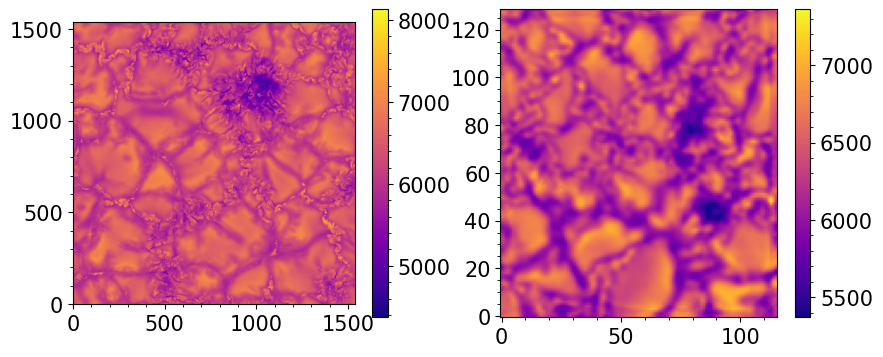

In [87]:
plt.figure(figsize=(10,4))
plt.subplot(121)
plt.imshow(T[:,:,30].T,origin='lower',cmap='plasma')
plt.colorbar()
plt.subplot(122)
plt.imshow(atm[1,1,:,:,10].T,origin='lower',cmap='plasma')
plt.colorbar()

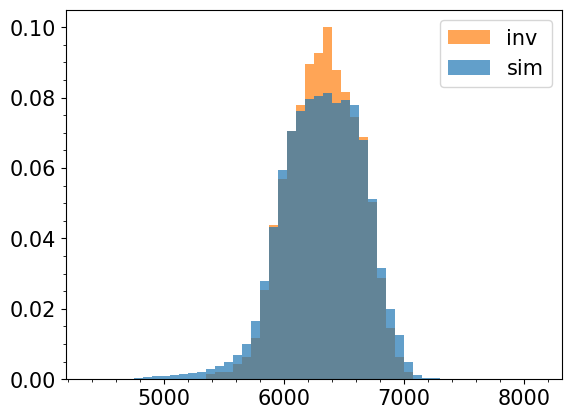

In [30]:
plt.hist([T[:,:,30].flatten(),atm[1,1,:,:,10].flatten()],bins=50,alpha=0.7,histtype='stepfilled',label=['sim','inv']
         ,weights=[[1/1536/1536]*1536*1536,[1/129/116]*129*116])
plt.legend()

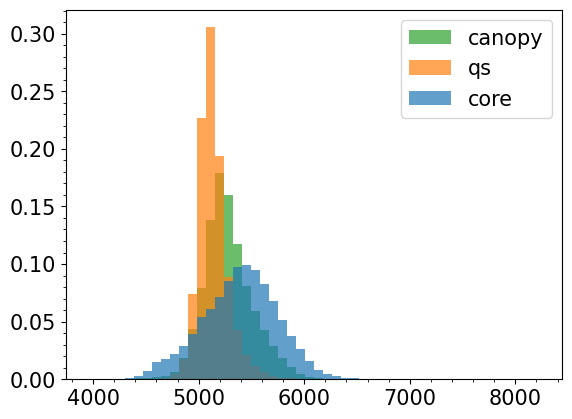

In [104]:
plt.hist([T[core[:,0],core[:,1],20],T[qs[:,0],qs[:,1],20],T[canopy[:,0],canopy[:,1],20]],bins=50,histtype='stepfilled',label=['core','qs','canopy'],alpha=0.7
         ,weights=[[1/core.shape[0]]*core.shape[0],[1/qs.shape[0]]*qs.shape[0],[1/canopy.shape[0]]*canopy.shape[0]])
plt.legend()

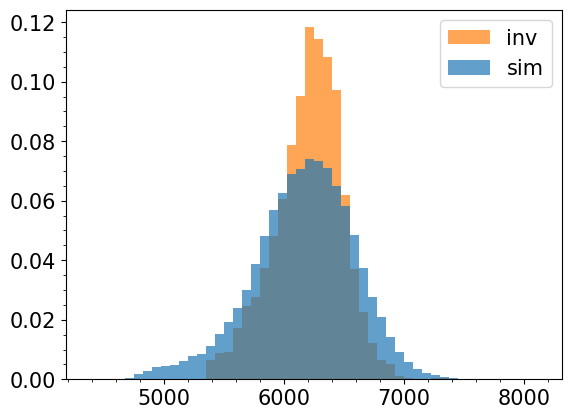

In [ ]:
plt.hist([T[core[:,0],core[:,1],10],atm[1,1,core_o[:,0],core_o[:,1],10]],bins=50,alpha=0.7,histtype='stepfilled',label=['sim','inv']
         ,weights=[[1/core.shape[0]]*core.shape[0],[1/core_o.shape[0]]*core_o.shape[0]])
plt.legend()

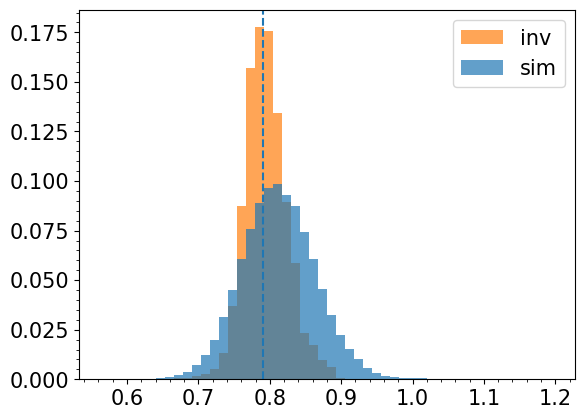

In [156]:
plt.hist([T[core[:,0],core[:,1],33]/T[core[:,0],core[:,1],10],atm[1,1,core_o[:,0],core_o[:,1],33]/atm[1,1,core_o[:,0],core_o[:,1],10]],bins=50,alpha=0.7,histtype='stepfilled',label=['sim','inv']
         ,weights=[[1/core.shape[0]]*core.shape[0],[1/core_o.shape[0]]*core_o.shape[0]])
plt.legend()
plt.axvline(0.79,ls='--')

In [155]:
np.mean(T[core[:,0],core[:,1],33]/T[core[:,0],core[:,1],10])

0.8130203181050891

(4000.0, 9000.0)

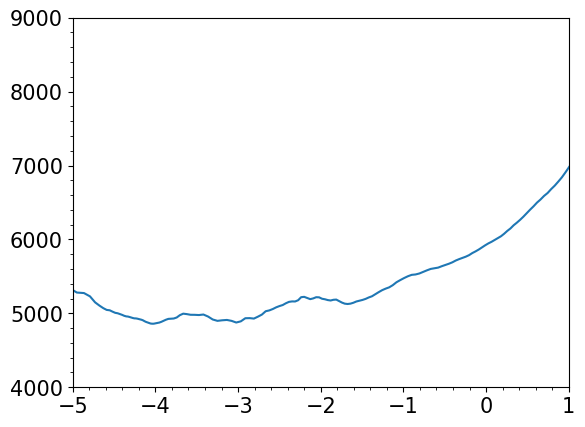

In [86]:
n = np.random.randint(core.shape[0])
x = core[n,0]
y = core[n,1]
plt.plot(sim.tau[x,y,:],sim.tem[x,y,:])
plt.xlim([-5,1])
plt.ylim([4000,9000])

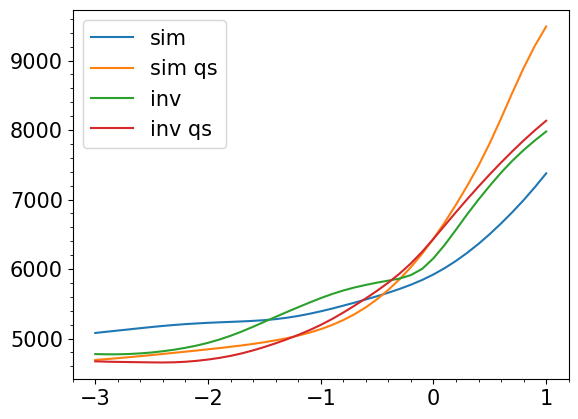

In [ ]:
plt.plot(tau_common,np.mean(T[450:500,350:400,:],axis=(0,1)),label='sim')
plt.plot(tau_common,np.mean(T[qs[:,0],qs[:,1],:],axis=0),label='sim qs')
plt.plot(tau_common,np.mean(atm[1,1,40:50,70:80,:41],axis=(0,1)),label='inv')
plt.plot(tau_common,np.mean(atm[1,1,qs_o[:,0],qs_o[:,1],:41],axis=0),label='inv qs')
plt.legend()

## B

## plasma $\beta$

$\beta = \frac{P_g}{\frac{B^2}{8\pi}}$

In [114]:
P[10,10,10]

28648.039356253645

In [115]:
atm[1,2,10,10,30]

18033.993966078684

In [105]:
beta_o = 8*np.pi*atm[1,2,:,:,:]/(atm[1,6,:,:,:]**2+atm[1,7,:,:,:]**2+atm[1,8,:,:,:]**2)

In [130]:
beta = 8*np.pi*P[:,:,:]/B[:,:,:]**2

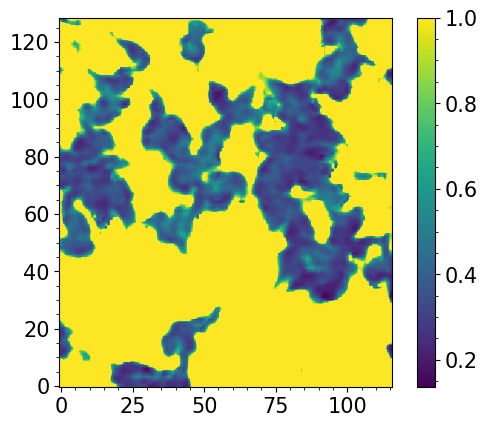

In [131]:
plt.imshow(beta_o[:,:,30].T,origin='lower',vmax=1)
plt.colorbar()

Text(0.5, 0.98, 'plasma $\\beta$ at $\\tau=0.01$')

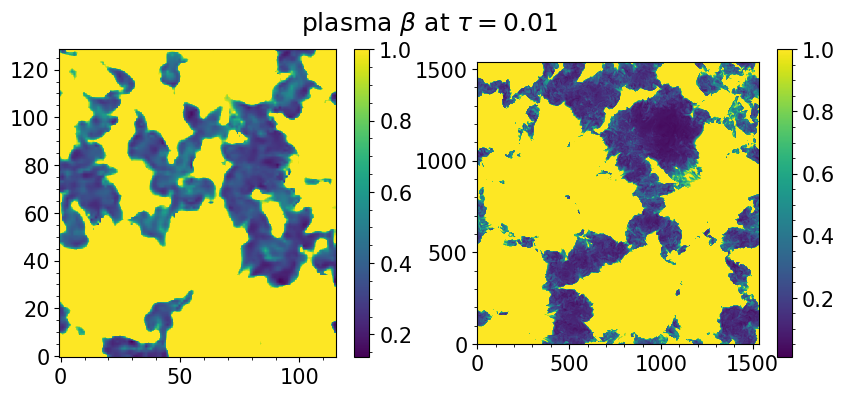

In [138]:
plt.figure(figsize=(10,4))
plt.subplot(121)
plt.imshow(beta_o[:,:,30].T,origin='lower',vmax=1)
plt.colorbar()
plt.subplot(122)
plt.imshow(beta[:,:,30].T,origin='lower',vmax=1)
plt.colorbar()
plt.suptitle(r'plasma $\beta$ at $\tau=0.01$')

(0.0, 0.0001)

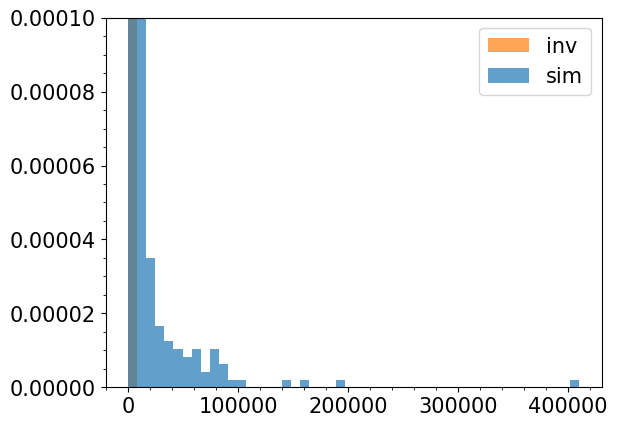

In [151]:
plt.hist([beta[core[:,0],core[:,1],30],beta_o[core_o[:,0],core_o[:,1],30]],bins=50,alpha=0.7,histtype='stepfilled',label=['sim','inv']
         ,weights=[[1/core.shape[0]]*core.shape[0],[1/core_o.shape[0]]*core_o.shape[0]])
plt.legend()
plt.ylim(0,0.0001)

In [153]:
print(np.mean(beta[core[:,0],core[:,1],30]))
print(np.mean(beta_o[core_o[:,0],core_o[:,1],30]))

12.401941334440423
0.359583962379677
